In [1]:
import pandas as pd

# Read the uploaded CSV file
df = pd.read_csv("train (1).csv")
# Display the first few rows
df.head()


,frequency,attack-angle,chord-length,free-stream-velocity,displacement-thickness,scaled-sound-pressure
0,605.307367,-0.063178,0.304707,55.751703,0.002637,127.669475
1,374.167361,9.880552,0.152504,31.679104,0.025590,128.887662
2,12483.334972,-0.096493,0.051875,31.833636,0.000731,119.060373
3,670.086704,3.989324,0.227804,31.557046,0.004998,130.356430
4,1003.855518,9.561850,0.024598,55.338644,0.004330,130.342105


In [2]:

#Separate input features (X) and the target variable (y)
X = df.drop(columns = ["scaled-sound-pressure"])
y = df["scaled-sound-pressure"]


**Attempt 1 (Plain Linear Regression Model)**

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


#Separate input features (X) and the target variable (y)
X = df.drop(columns = ["scaled-sound-pressure"])
y = df["scaled-sound-pressure"]


#Split the data into training and testing sets (80% training ,20% testing)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 1)

#Initialize the linear regression model
lr_model = LinearRegression()

#Train the model on the training data
lr_model.fit(X_train, y_train)

#Predict on the test set
y_pred = lr_model.predict(X_test)

#Score the performance of the  test set
r2 = r2_score(y_test, y_pred)

#Display coeficients and intercept

print(f"R-squared (R²) Score: {r2:.4f}")



R-squared (R²) Score: 0.4117


**Attempt with Cross Validation**

In [4]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer, r2_score

#1) Separate input features (X) and the target variable (y)
X = df.drop(columns = ["scaled-sound-pressure"])
y = df["scaled-sound-pressure"]


#2) Split the data into training and testing sets (80% training ,20% testing)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 1)

#3) Initialize the linear regression model
lr_model = LinearRegression()


#4) Define K-fold cross validation settings
k = 5 # of folds

kf = KFold(n_splits = k, shuffle = True, random_state = 1) #shuffle only once for consistency



#Define the scoring metric 4

mse_scorer = make_scorer(mean_squared_error, greater_is_better = False)

#Perform cross_validation

cv_mse_scores = cross_val_score(lr_model, X, y, cv = kf, scoring = mse_scorer)

cv_r2_scores = cross_val_score(lr_model, X, y, cv = kf, scoring = 'r2')

#Convert negative scores into positive MSE values
cv_mse_scores = -cv_mse_scores


#Score calcualtion

# MSE score (sensitive to outliers)
#print(f"Cross-Validated MSE scores (each fold): {cv_mse_scores}")
#print(f"Average CV MSE: {np.mean(cv_mse_scores):.4f}")
#print(f"Standard Deviation of CV MSE: {np.std(cv_mse_scores):.4f}")


print(f"Cross_Validated R^2 scores (each fold): {cv_r2_scores}")
print(f"Average CV R²: {np.mean(cv_r2_scores):.4f}")
print(f"Standard Deviation of CV R²: {np.std(cv_r2_scores):.4f}")



#Display coeficients and intercept  (intuitive)

print(f"R-squared (R²) Score: {r2:.4f}")

Cross_Validated R^2 scores (each fold): [0.41171249 0.55640797 0.56223193 0.52100019 0.528256  ]
Average CV R²: 0.5159
Standard Deviation of CV R²: 0.0544
R-squared (R²) Score: 0.4117


**Ridge regression with Cross validation**

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso

#Initialize ridge regression
ridge = Lasso()

#Define a grid search of alpha values (regularization strength)
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
param_grid = {'alpha': alpha_values}

#Use GridSearchCV to tune alpha using 5 fold cross validation
grid_search = GridSearchCV(
    ridge,
    param_grid,
    cv = 5,
    scoring = 'r2',
    return_train_score = True
)

#Fit the grid search
grid_search.fit(X,y)


#

final_model = grid_search.best_estimator_


# 6. Retrieve and convert results to DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)


#Redabiility
results_df['alpha'] = results_df['param_alpha']

# 8. Display only relevant columns
results_df['mean_train_r2'] = results_df['mean_train_score']
results_df['mean_cv_r2'] = results_df['mean_test_score']
results_df = results_df[['alpha', 'mean_train_r2', 'mean_cv_r2']]

##xtract the best alpha and correspondin model
best_alpha = grid_search.best_params_["alpha"]
best_model = grid_search.best_estimator_
best_score = grid_search.best_score_




# 9. Print the best alpha and corresponding cross-validated MSE
best_alpha = grid_search.best_params_['alpha']
best_cv_score = grid_search.best_score_

print("Best Alpha:", best_alpha)
print("Highest Cross-Validated r2 (generalization error):", best_cv_score)
print("\nTrain vs. CV r2 by Alpha:")
print(results_df.sort_values("alpha"))

Best Alpha: 0.001
Highest Cross-Validated r2 (generalization error): 0.5186548700965778

Train vs. CV r2 by Alpha:
      alpha  mean_train_r2  mean_cv_r2
0     0.001       0.529301    0.518655
1     0.010       0.502197    0.491774
2     0.100       0.457883    0.449681
3     1.000       0.279841    0.267640
4    10.000       0.200270    0.186592
5   100.000       0.156881    0.145739
6  1000.000       0.154717    0.144984


**Residual vs Predicted Scaled Sound Pressure (To check for Linearity of data)**

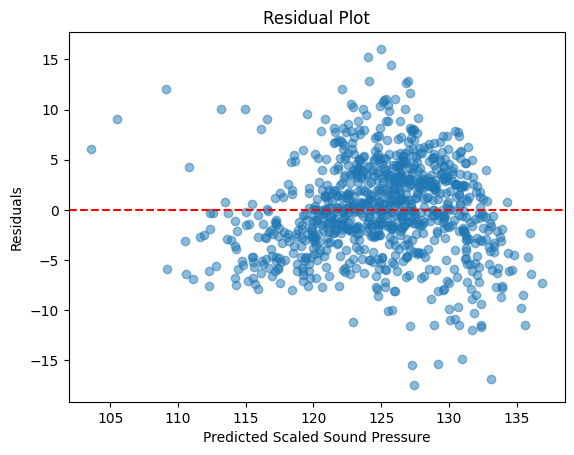

In [6]:
import matplotlib.pyplot as plt

y_pred = final_model.predict(X)
residuals = y - y_pred

# Residual plot
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Scaled Sound Pressure")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Predicted vs Actual Sound Scale Pressure (to measure Linearity)**

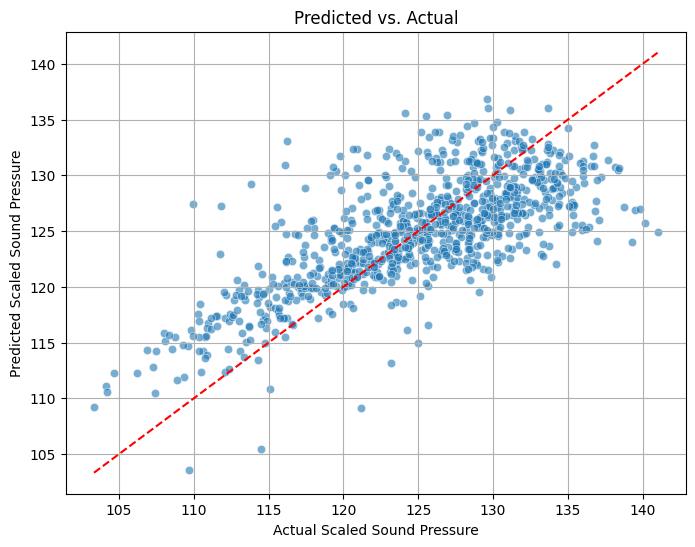

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict using the trained model
y_pred = final_model.predict(X)

# Plot: Predicted vs. Actual
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # Perfect prediction line
plt.xlabel("Actual Scaled Sound Pressure")
plt.ylabel("Predicted Scaled Sound Pressure")
plt.title("Predicted vs. Actual")
plt.grid(True)
plt.show()


**Normal Distribution of residuals**

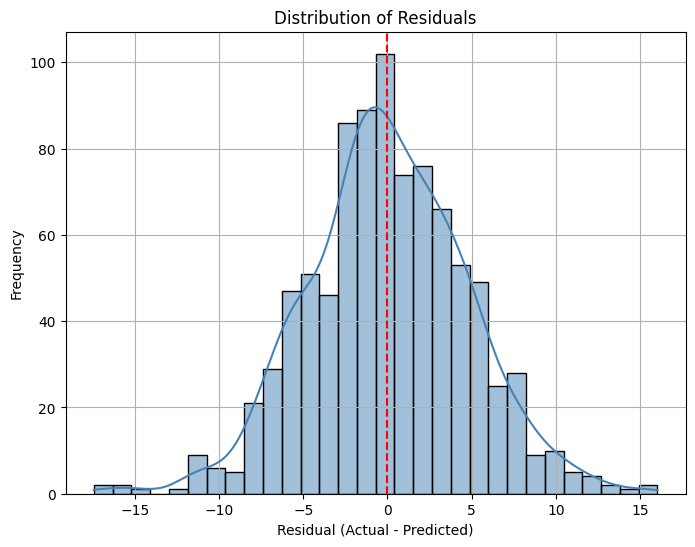

In [8]:
# Calculate residuals (errors)
residuals = y - y_pred

# Plot: Distribution of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30, color='steelblue')
plt.axvline(0, color='red', linestyle='--')  # Center line
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.show()


**Check for Skew in the Variables**

1.   Frequency   (strong right skew)
2.   Attack-angle (weak right skew)
3.   chord-length
4.   free-stream-velocity
5.    Displacement thickness (strong right skew)



HOWEVER NOTICE THAT MODEL LIKES PRESERVING EVEN WITH SKEW, LOG WON"T HELP


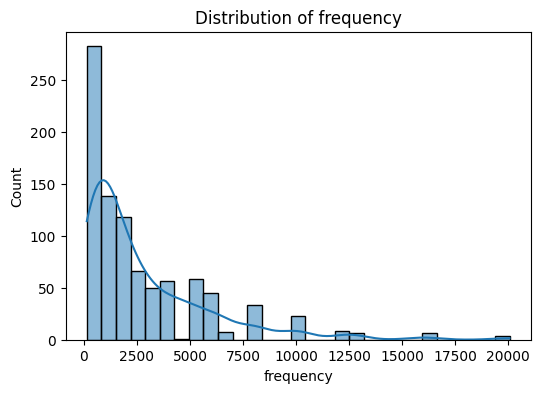

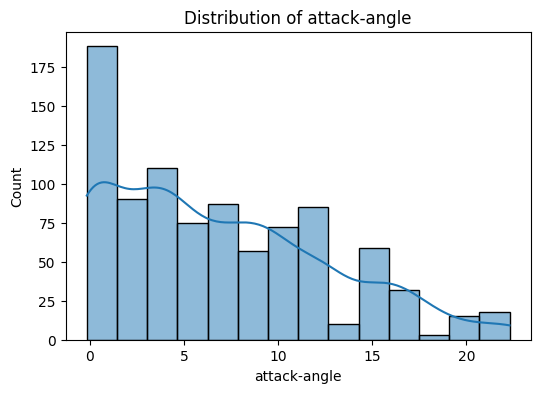

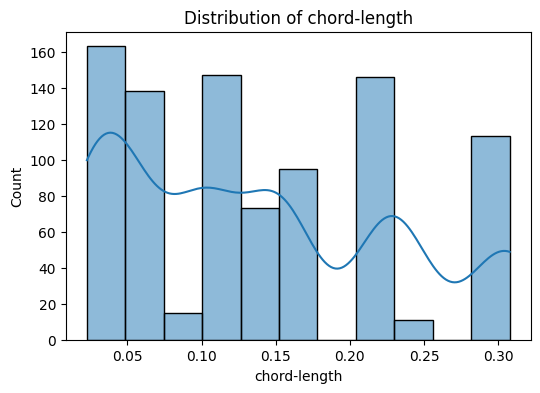

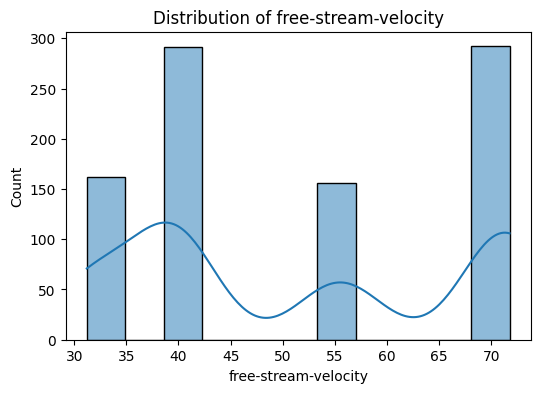

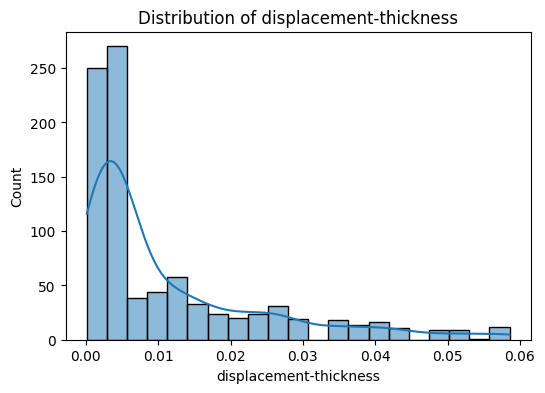

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in X.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


In [10]:
##DIDN"T WORK. MODEL LIKES PRESERVING FEATURES EVEN WITH SKEW, SO LOG WON"T HELP.

import numpy as np
X_log =  X.copy()

log_features = ["frequency"]

for feature in log_features:
  X_log[feature] = np.log1p(X_log[feature])

**GridSearch and Ridge Regression along with StandardScaler Preprocessing**

**GridSearch**: technique used to find the optimal set of hyperparameters for a model by exhaustively trying every possible combination of values you define

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

#Initialize ridge regression
ridge = Ridge()

#Define a grid search of alpha values (regularization strength)
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
param_grid = {'alpha': alpha_values}

#Use GridSearchCV to tune alpha using 5 fold cross validation
grid_search = GridSearchCV(
    ridge,
    param_grid,
    cv = 5,
    scoring = 'r2',
    return_train_score = True
)

#Fit the grid search
grid_search.fit(X,y)


#

final_model = grid_search.best_estimator_


# 6. Retrieve and convert results to DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)


#Redabiility
results_df['alpha'] = results_df['param_alpha']

# 8. Display only relevant columns
results_df['mean_train_r2'] = results_df['mean_train_score']
results_df['mean_cv_r2'] = results_df['mean_test_score']
results_df = results_df[['alpha', 'mean_train_r2', 'mean_cv_r2']]

##xtract the best alpha and correspondin model
best_alpha = grid_search.best_params_["alpha"]
best_model = grid_search.best_estimator_
best_score = grid_search.best_score_




# 9. Print the best alpha and corresponding cross-validated MSE
best_alpha = grid_search.best_params_['alpha']
best_cv_score = grid_search.best_score_

print("Best Alpha:", best_alpha)
print("Highest Cross-Validated r2 (generalization error):", best_cv_score)
print("\nTrain vs. CV r2 by Alpha:")
print(results_df.sort_values("alpha"))

Best Alpha: 0.001
Highest Cross-Validated r2 (generalization error): 0.5189469838111079

Train vs. CV r2 by Alpha:
      alpha  mean_train_r2  mean_cv_r2
0     0.001       0.529572    0.518947
1     0.010       0.528603    0.518317
2     0.100       0.513641    0.504895
3     1.000       0.489716    0.482121
4    10.000       0.391296    0.381621
5   100.000       0.298234    0.286499
6  1000.000       0.282323    0.270219


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define pipeline: scaling + Ridge regression
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Define alpha values to search
param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# GridSearchCV with 5-fold CV
grid = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X, y)

# Best model summary
print("Best Alpha (with scaling):", grid.best_params_['ridge__alpha'])
print("Best Cross-Validated R² (with scaling):", grid.best_score_)


Best Alpha (with scaling): 1
Best Cross-Validated R² (with scaling): 0.5189432304811724


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Create pipeline with polynomial features, scaling, and Ridge regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),  # Degree 2 = adds x² and interactions
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Define alpha values to search for Ridge
param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Grid search with 5-fold CV
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X, y)

# Extract best model and evaluate training R²
best_model = grid.best_estimator_
train_r2 = best_model.score(X, y)  # R² on training data

# Output results
print("Best alpha with poly features:", grid.best_params_['ridge__alpha'])
print("Best CV R² with poly features:", grid.best_score_)
print("Training R² with poly features:", train_r2)




Best alpha with poly features: 1
Best CV R² with poly features: 0.7230360307285357
Training R² with poly features: 0.7514888044248436


**Displaying top features with GridSearch**

In [15]:
# Get feature names from the PolynomialFeatures step
feature_names = best_model.named_steps['poly'].get_feature_names_out(X.columns)

# Get corresponding coefficients from the Ridge regression step
coefficients = best_model.named_steps['ridge'].coef_

# Combine names and coefficients into a sorted list (by absolute value)
top_features = sorted(zip(feature_names, coefficients), key=lambda x: abs(x[1]), reverse=True)

# Display the top N features
N = 20  # Change this to see more or fewer
print(f"Top {N} most impactful polynomial features:\n")
for name, coef in top_features[:N]:
    print(f"{name}: {coef:.4f}")


Top 20 most impactful polynomial features:

frequency chord-length: -11.3260
frequency^2: -9.6648
frequency displacement-thickness: -8.5061
frequency^3: 5.3775
frequency: 4.8251
frequency free-stream-velocity: 4.5862
frequency displacement-thickness^2: 4.5665
frequency chord-length^2: 4.4718
frequency^2 chord-length: 4.4097
displacement-thickness: 3.6234
frequency^2 free-stream-velocity: -3.5051
free-stream-velocity displacement-thickness: 3.4933
attack-angle^2: -3.3497
attack-angle^2 free-stream-velocity: -3.3416
attack-angle^3: 3.3276
frequency attack-angle^2: 3.3250
attack-angle free-stream-velocity^2: 2.4483
chord-length^2: -2.3928
frequency^2 displacement-thickness: 2.3322
attack-angle chord-length: 1.8959


In [16]:
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV

# Create pipeline: polynomial features + scaling + gradient descent Ridge
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(penalty='l2', max_iter=10000, random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'sgd__alpha': [0.0001, 0.001, 0.01],  # L2 regularization strength
    'sgd__eta0': [0.001, 0.01, 0.1],       # Initial learning rate
    'sgd__learning_rate': ['constant'],   # You can try 'invscaling' or 'adaptive' too
}

# Run GridSearchCV
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X, y)

# Report results
best_model = grid.best_estimator_
train_r2 = best_model.score(X, y)

print("Best Params (Gradient Descent Ridge):", grid.best_params_)
print("Best CV R²:", grid.best_score_)
print("Training R²:", train_r2)


Best Params (Gradient Descent Ridge): {'sgd__alpha': 0.0001, 'sgd__eta0': 0.001, 'sgd__learning_rate': 'constant'}
Best CV R²: 0.673133966496842
Training R²: 0.6967012430763839


**Optionally uses PCA - fails **

In [17]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Step 1: Build pipeline
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # Keep 95% of variance
    ('ridge', Ridge())
])

# Step 2: Define alpha grid
param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10]
}

# Step 3: Grid search with 5-fold CV
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X, y)

# Step 4: Print results
print("Best alpha (with PCA):", grid.best_params_['ridge__alpha'])
print("Best CV R² (with PCA):", grid.best_score_)
print("Training R² (with PCA):", grid.best_estimator_.score(X, y))

# Step 5 (Optional): View how many components PCA kept
n_components_used = grid.best_estimator_.named_steps['pca'].n_components_
print("Number of principal components used:", n_components_used)


Best alpha (with PCA): 10
Best CV R² (with PCA): 0.5949745075602026
Training R² (with PCA): 0.6200517503165168
Number of principal components used: 9


**Try Random Forest along with GridSearch**

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

# (Optional) scale features — RF is tree-based and doesn't need scaling, but you can still include it
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42))
])

# Define grid of hyperparameters
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
}

# Grid search with 5-fold CV
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X, y)

# Evaluate
best_model = grid.best_estimator_
train_r2 = best_model.score(X, y)

print("Best Parameters (Random Forest):", grid.best_params_)
print("CV R² (Random Forest):", grid.best_score_)
print("Training R² (Random Forest):", train_r2)


Best Parameters (Random Forest): {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
CV R² (Random Forest): 0.8493605757924263
Training R² (Random Forest): 0.9810383814399396


**Try XG Boost with Grid Search**

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Create pipeline (optional StandardScaler — XGBoost is tree-based, so not required)
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # You can remove this if you're sure it's unnecessary
    ('xgb', XGBRegressor(objective='reg:squarederror', random_state=1))
])

# 2. Define hyperparameter grid
param_grid = {
    'xgb__n_estimators': [400],
    'xgb__max_depth': [5], #out of [3,5,7]
    'xgb__learning_rate': [0.1],

    'xgb__subsample': [0.8], #out of [0.8, 1]
    'xgb__colsample_bytree': [1.0],
    'xgb__reg_alpha': [0.1],
    'xgb__reg_lambda': [10], #out of [1,5,10]
    'xgb__min_child_weight': [5],
    'xgb__gamma': [0],
}


# 3. Grid search with 5-fold CV
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1  # Use all cores
)

# 4. Fit to data
grid.fit(X, y)

# 5. Evaluate
best_model = grid.best_estimator_
train_r2 = best_model.score(X, y)

print("✅ Best Params (XGBoost):", grid.best_params_)
print("📈 CV R² (XGBoost):", grid.best_score_)
print("🎯 Training R² (XGBoost):", train_r2)


✅ Best Params (XGBoost): {'xgb__colsample_bytree': 1.0, 'xgb__gamma': 0, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 400, 'xgb__reg_alpha': 0.1, 'xgb__reg_lambda': 10, 'xgb__subsample': 0.8}
📈 CV R² (XGBoost): 0.8783300260140792
🎯 Training R² (XGBoost): 0.9928821767065767


In [19]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.2 MB/s eta 0:00:00


In [20]:
!pip install shap


In [21]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 10),
        'random_state': 1,
        'objective': 'reg:squarederror'
    }

    model = XGBRegressor(**params)
    cv = KFold(n_splits=5, shuffle=True, random_state=1)
    score = cross_val_score(model, X, y, cv=cv, scoring='r2', n_jobs=-1)
    return score.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("🔍 Best Parameters:", study.best_params)
print("📈 Best CV R²:", study.best_value)


[I 2025-11-14 19:02:41,123] A new study created in memory with name: no-name-fdaed5d9-3884-4954-9cdb-11e9e1e7c91b
/tmp/ipython-input-4046289042.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/tmp/ipython-input-4046289042.py:11: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
/tmp/ipython-input-4046289042.py:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree',

🔍 Best Parameters: {'n_estimators': 329, 'learning_rate': 0.09144205760202392, 'max_depth': 6, 'subsample': 0.6021950991361209, 'colsample_bytree': 0.8878562822471361, 'reg_alpha': 3.943476850443418, 'reg_lambda': 4.824958054731147}
📈 Best CV R²: 0.8656410549732036


**Grid SearchCV,  XG Boost , along with relevant Feature Engineering based on Optuna relevance**

In [24]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# 🧠 Step 1: Feature Engineering
X["freq_vel_interaction"] = X["frequency"] * X["free-stream-velocity"]
X["strouhal"] = (X["frequency"] * X["chord-length"]) / X["free-stream-velocity"]
X["log_frequency"] = np.log1p(X["frequency"])
X["log_velocity"] = np.log1p(X["free-stream-velocity"])
X["freq_squared"] = X["frequency"] ** 2
X["velocity_squared"] = X["free-stream-velocity"] ** 2
X["velocity5_thickness"] = (X["free-stream-velocity"] ** 5) * X["displacement-thickness"]
X["log_velocity5_thickness"] = np.log1p(X["velocity5_thickness"])

# ✂️ Optional: Drop original velocity5_thickness if log version is more stable
X.drop(columns=["velocity5_thickness"], inplace=True)

# 🎯 Step 2: Train/test split for safety (not used during GridSearch)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ⚙️ Step 3: Define pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(objective='reg:squarederror', random_state=1))
])

param_grid = {
    'xgb__n_estimators': [480],
    'xgb__max_depth': [9], #out of [3,5,7]
    'xgb__learning_rate': [0.10704067150254538],

    'xgb__subsample': [0.8], #chose 0.8 and 0.66
    'xgb__colsample_bytree': [1.0], #0.5 to 1
    'xgb__reg_alpha': [0.1],
    'xgb__reg_lambda': [10], #out of [1,5,10]
    'xgb__min_child_weight': [5],
    'xgb__gamma': [0],
}

# 🔍 Step 5: GridSearchCV setup
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 🚀 Step 6: Fit model to training data
grid.fit(X_train, y_train)

# 📈 Step 7: Evaluation
print("✅ Best Params:", grid.best_params_)
print("📈 Best CV R²:", grid.best_score_)

# Training R² on full training data
best_model = grid.best_estimator_
train_r2 = best_model.score(X_train, y_train)
print("🎯 Training R²:", train_r2)


#Parameters: {'n_estimators': 490, 'learning_rate': 0.10704067150254538, 'max_depth': 9, 'subsample': 0.6642424396102804, 'colsample_bytree': 0.8589839298804357, 'reg_alpha': 9.42321541399761, 'reg_lambda': 7.137013064118139}

Fitting 5 folds for each of 1 candidates, totalling 5 fits
✅ Best Params: {'xgb__colsample_bytree': 1.0, 'xgb__gamma': 0, 'xgb__learning_rate': 0.10704067150254538, 'xgb__max_depth': 9, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 480, 'xgb__reg_alpha': 0.1, 'xgb__reg_lambda': 10, 'xgb__subsample': 0.8}
📈 Best CV R²: 0.9003365444692536
🎯 Training R²: 0.9999525507899123
